# 01 — Animal Overview Reports

Per-animal psychometric curves, update matrices and summary statistics, by condition.
Phase analysis lives in `analysis/phase.py`; this notebook just drives and plots it.

## Setup

In [1]:
%matplotlib inline
from shared_setup import *
from analysis.phase import Phase, calculate_phase

experiment, info = load_data()
print(f"Mode: {info['mode']}")

Loaded snapshot: 22 animals, 1185 sessions (exported 2026-06-09)
Mode: snapshot


/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/notebooks/shared_setup.py:193: UserWarning: Snapshot is 170h old (exported 2026-06-09T12:49:35.485965+00:00). Re-export if new sessions have been collected.
  experiment, meta = load_snapshot(


## Interactive: single animal

In [2]:
animal_id = 'SS16'   # ← change this
animal = experiment.get_animal(animal_id)
tag = f'{animal_id} ({animal.genotype.upper()})'
print(f'Report for {tag}')

Report for SS16 (HET)


### Uniform

In [27]:
phases_uniform = [
    Phase('uniform_training_last5', 'all', 'Last5 Sessions', get_colour(0)),
    Phase('uniform_masking', 'all', 'Masking Sessions', get_colour(1)),
    Phase('uniform_opto', 'all', 'Opto Sessions', get_colour(2)),
    Phase('uniform_opto', 'non_opto', 'Non-Opto Trials', get_colour(3)),
    Phase('uniform_opto', 'opto', 'Opto Trials', get_colour(4)),
    Phase('uniform_opto', 'post_opto', 'Post-Opto Trials', get_colour(5)),
]
plotting_pairs = [(0,1), (1,2), (0,2), (2,3), (3,4), (4,5)]

In [28]:
phases_uniform = calculate_phase(animal, phases_uniform, min_accuracy=0.6, min_trials=10, down_sample=False)

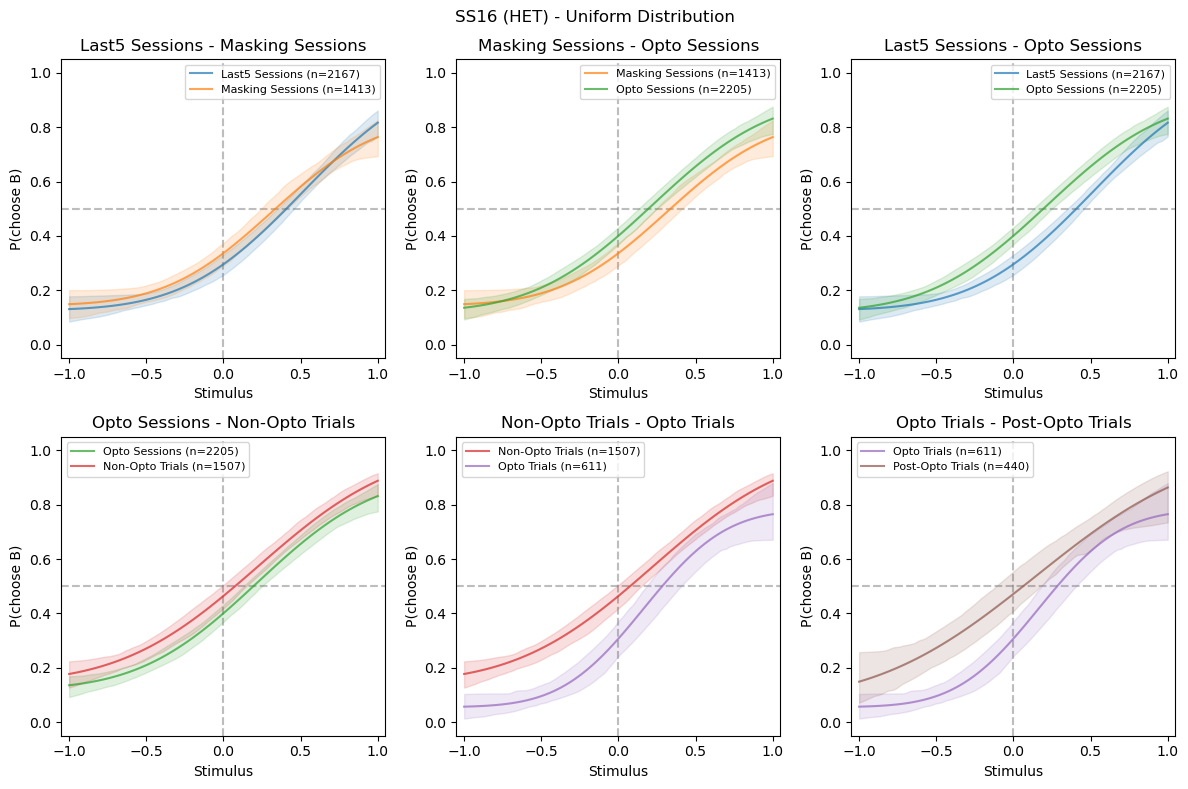

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, pair in zip(axes, plotting_pairs):
    title = ''
    for idx in pair:
        p = phases_uniform[idx]
        if p.psyc_fit is None:
            continue
        plot_psychometric(p.psyc_fit, ax=ax, color=p.color, show_ci=True, label=f'{p.label} (n={p.pooled["n_trials"]})')
        title += f'{p.label} - '
    ax.set_title(title.rstrip(' -'))
    ax.legend(fontsize=8)

fig.suptitle(f'{tag} - Uniform Distribution')
fig.tight_layout()

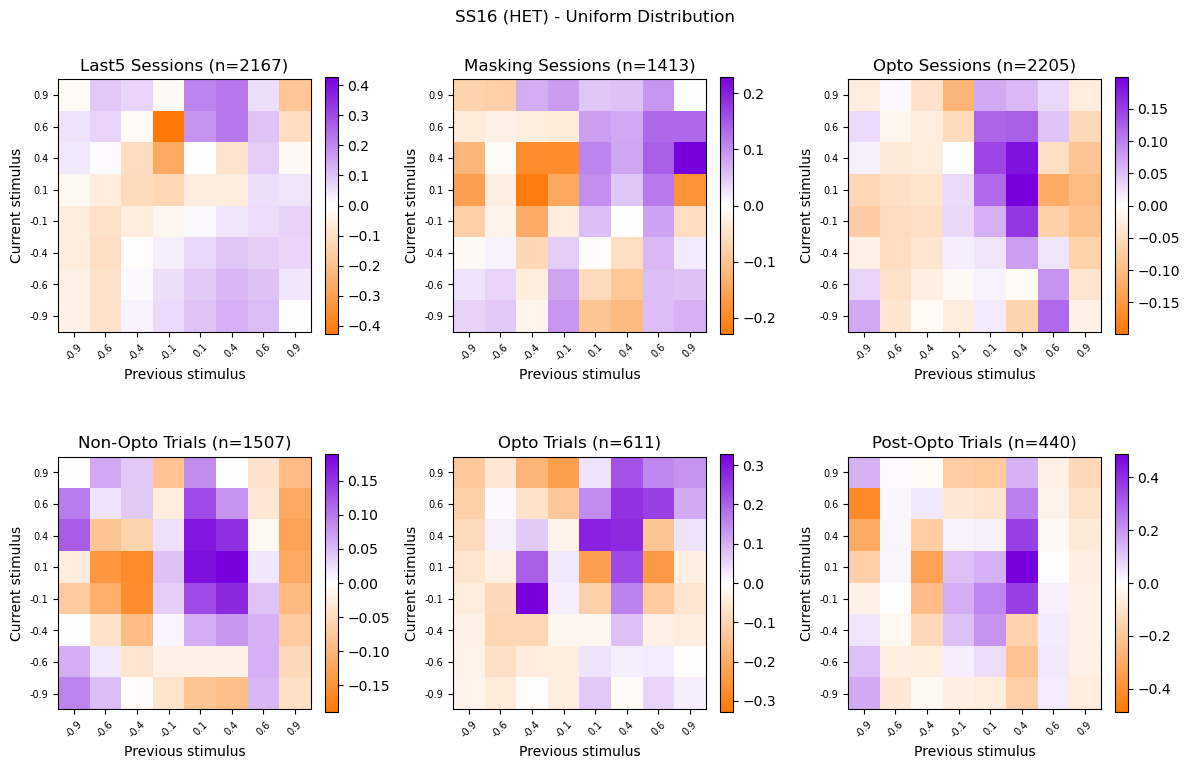

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, idx in zip(axes, range(len(phases_uniform))):
    p = phases_uniform[idx]
    if p.um_fit is None:
        continue
    plot_um(p.um_fit[0], ax=ax)
    ax.set_title(f'{p.label} (n={p.pooled["n_trials"]})')

fig.suptitle(f'{tag} - Uniform Distribution')
fig.tight_layout()

### Hard A / Hard B

In [34]:
phases_hard = [
    Phase('hard_a_masking', 'all', 'Hard A - Masking', get_colour(0)),
    Phase('hard_a_opto', 'all', 'Hard A - All', get_colour(1)),
    Phase('hard_a_opto', 'non_opto', 'Hard A - Non-Opto', get_colour(2)),
    Phase('hard_a_opto', 'opto', 'Hard A - Opto', get_colour(3)),
    Phase('hard_a_opto', 'post_opto', 'Hard A - Post-Opto', get_colour(4)),
    Phase('hard_b_masking', 'all', 'Hard B - Masking', get_colour(5)),
    Phase('hard_b_opto', 'all', 'Hard B - All', get_colour(6)),
    Phase('hard_b_opto', 'non_opto', 'Hard B - Non-Opto', get_colour(7)),
    Phase('hard_b_opto', 'opto', 'Hard B - Opto', get_colour(8)),
    Phase('hard_b_opto', 'post_opto', 'Hard B - Post-Opto', get_colour(9)),
]
plotting_pairs = [(0,2), (2,3), (3,4),
                  (5,7), (7,8), (8,9),
                  (0,5), (2,7), (3,8)]

In [35]:
phases_hard = calculate_phase(animal, phases_hard, min_accuracy=0.6, min_trials=10, down_sample=False)

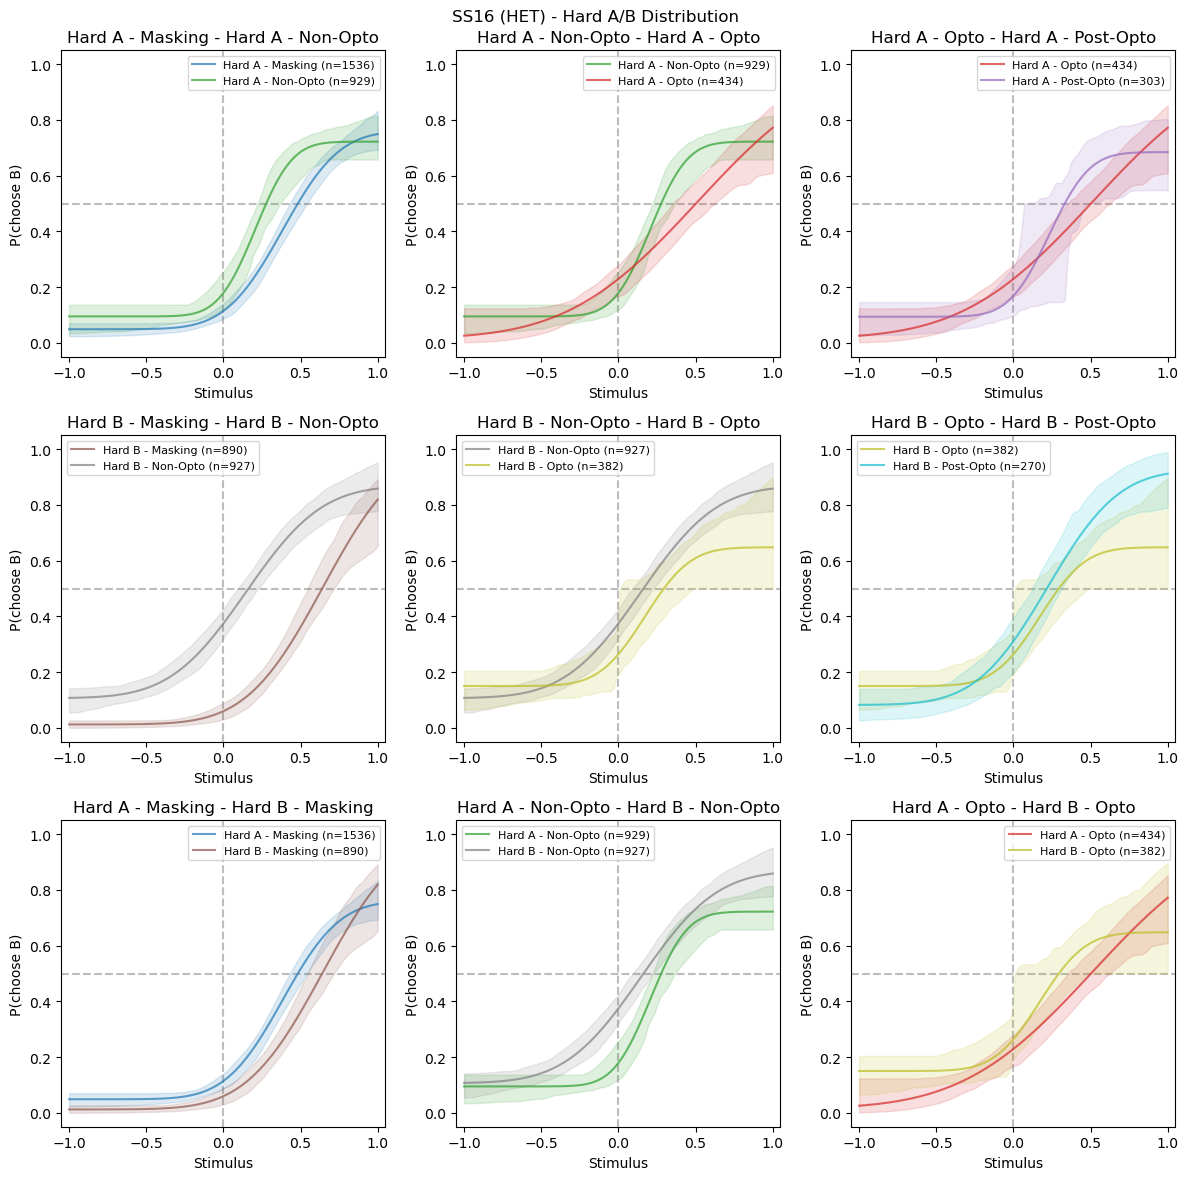

In [36]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for ax, pair in zip(axes, plotting_pairs):
    title = ''
    for idx in pair:
        p = phases_hard[idx]
        if p.psyc_fit is None:
            continue
        plot_psychometric(p.psyc_fit, ax=ax, color=p.color, label=f'{p.label} (n={p.pooled["n_trials"]})')
        title += f'{p.label} - '
    ax.set_title(title.rstrip(' -'))
    ax.legend(fontsize=8)

fig.suptitle(f'{tag} - Hard A/B Distribution')
fig.tight_layout()

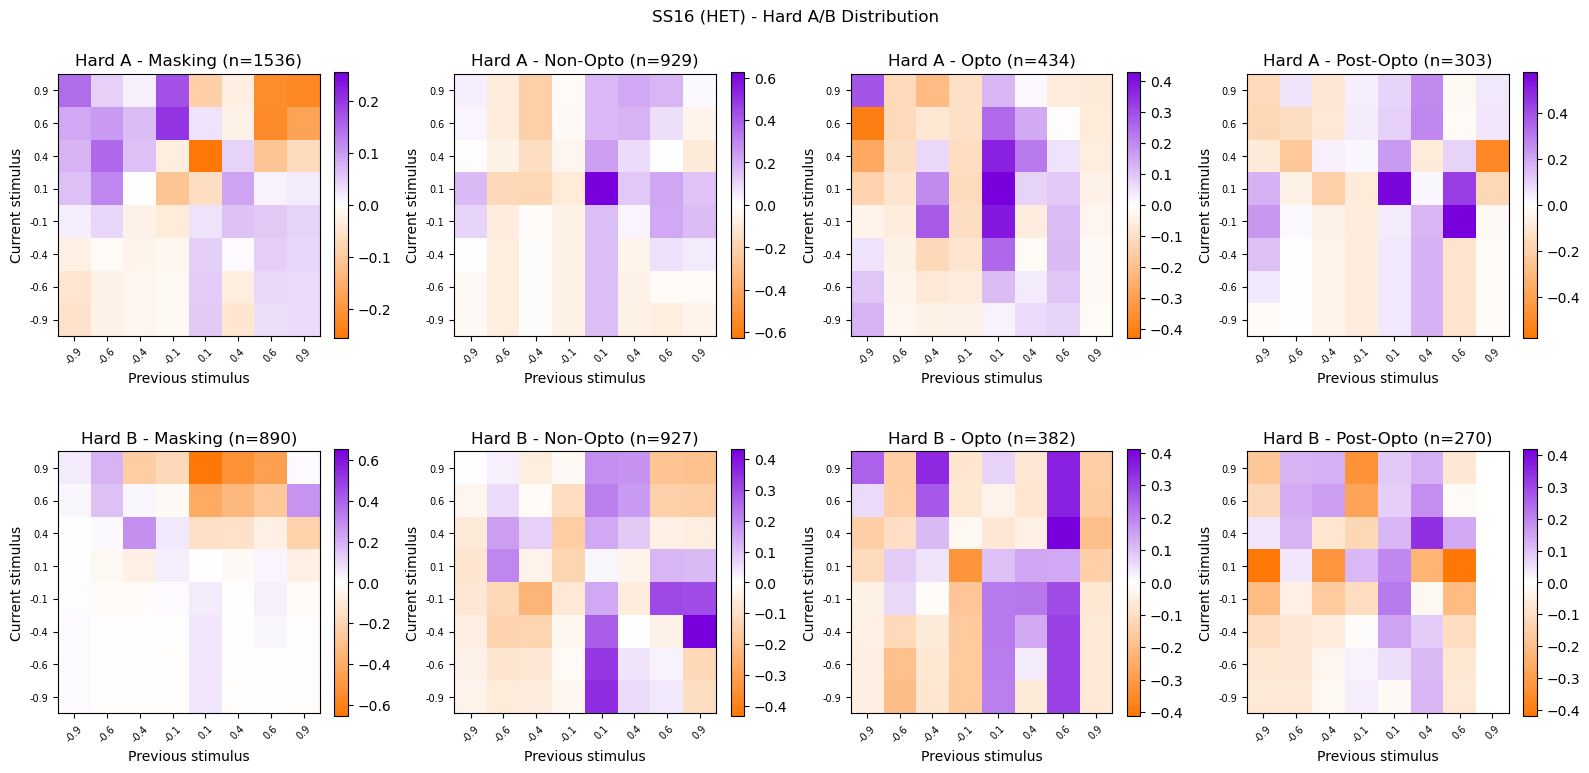

In [37]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, idx in zip(axes, [0, 2, 3, 4, 5, 7, 8, 9]):
    p = phases_hard[idx]
    if p.um_fit is None:
        continue
    plot_um(p.um_fit[0], ax=ax)
    ax.set_title(f'{p.label} (n={p.pooled["n_trials"]})')

fig.suptitle(f'{tag} - Hard A/B Distribution')
fig.tight_layout()

## Downsampled (matched n)

Fresh `Phase` lists — `calculate_phase` fills objects in place, so the downsampled run
must not reuse the lists above.

In [38]:
phases_uniform_ds = [
    Phase('uniform_training_last5', 'all', 'Last5 Sessions', get_colour(0)),
    Phase('uniform_masking', 'all', 'Masking Sessions', get_colour(1)),
    Phase('uniform_opto', 'all', 'Opto Sessions', get_colour(2)),
    Phase('uniform_opto', 'non_opto', 'Non-Opto Trials', get_colour(3)),
    Phase('uniform_opto', 'opto', 'Opto Trials', get_colour(4)),
    Phase('uniform_opto', 'post_opto', 'Post-Opto Trials', get_colour(5)),
]
plotting_pairs = [(0,1), (1,2), (0,2), (2,3), (3,4), (4,5)]

In [39]:
phases_uniform_ds = calculate_phase(animal, phases_uniform_ds, min_accuracy=0.6, min_trials=10, down_sample=True)

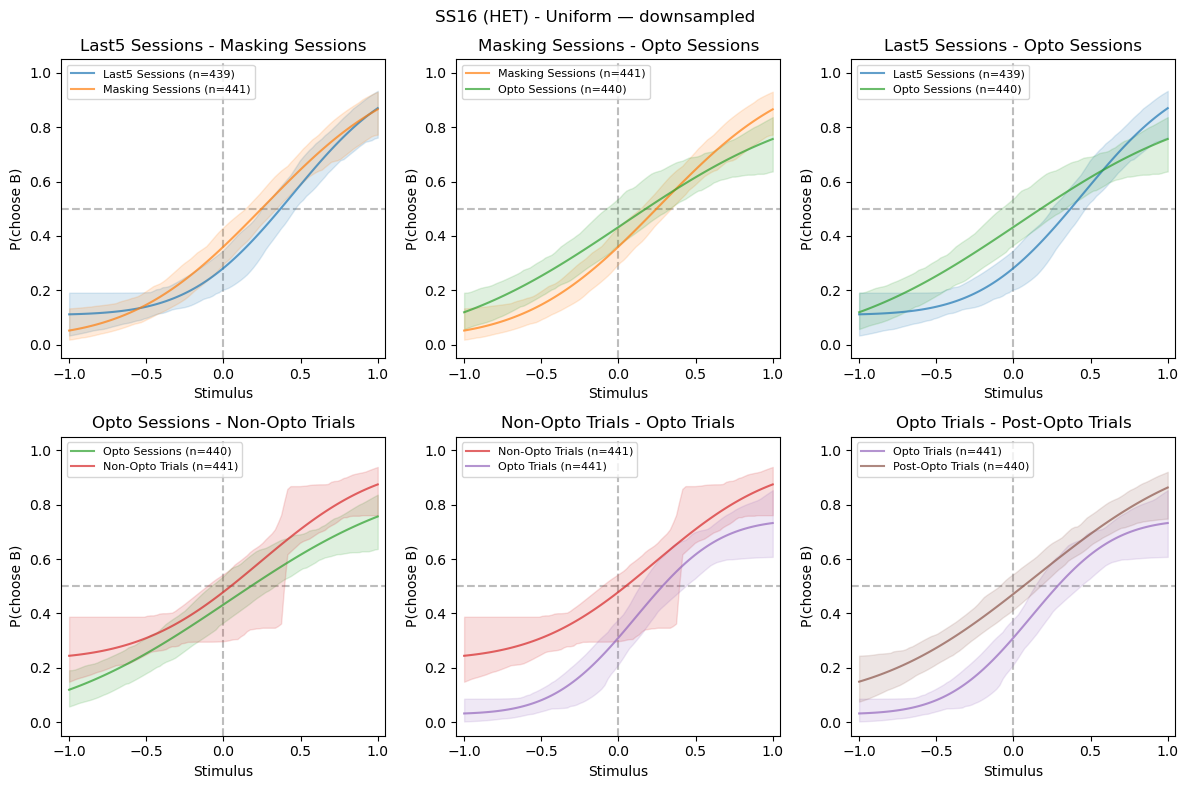

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, pair in zip(axes, plotting_pairs):
    title = ''
    for idx in pair:
        p = phases_uniform_ds[idx]
        if p.psyc_fit is None:
            continue
        plot_psychometric(p.psyc_fit, ax=ax, color=p.color, show_ci=True, label=f'{p.label} (n={p.pooled["n_trials"]})')
        title += f'{p.label} - '
    ax.set_title(title.rstrip(' -'))
    ax.legend(fontsize=8)

fig.suptitle(f'{tag} - Uniform — downsampled')
fig.tight_layout()

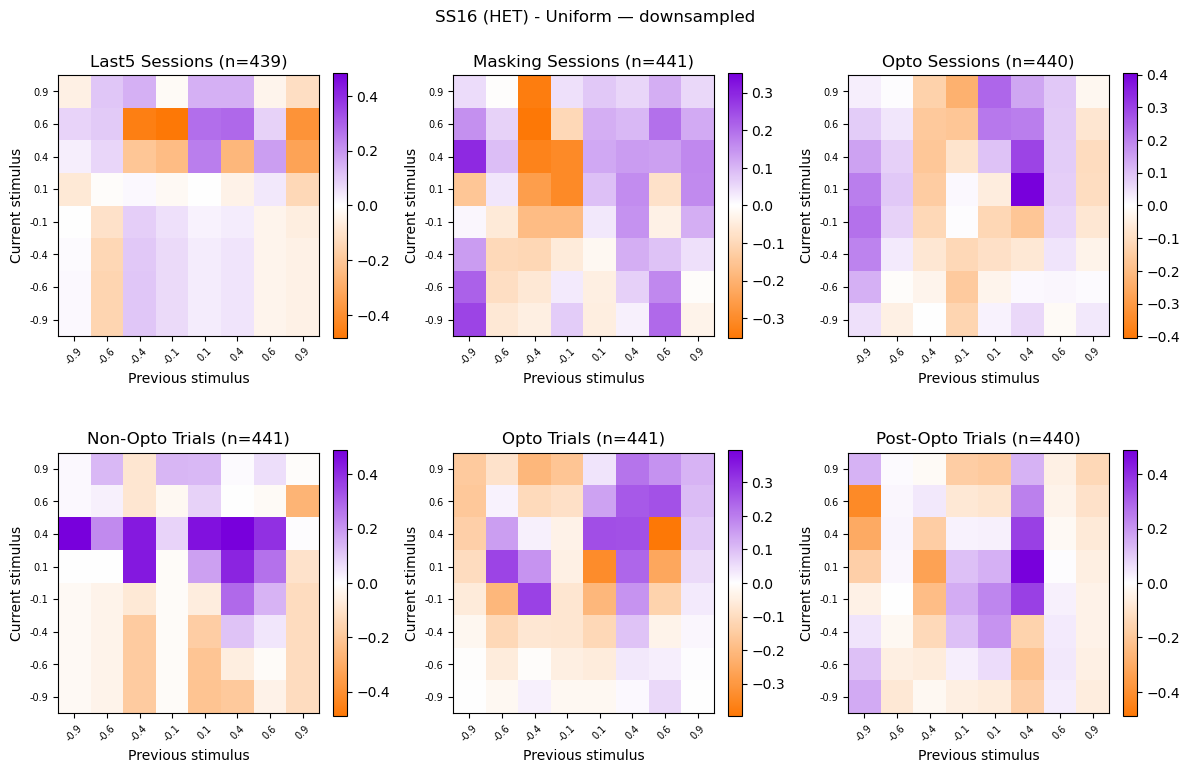

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, idx in zip(axes, range(len(phases_uniform_ds))):
    p = phases_uniform_ds[idx]
    if p.um_fit is None:
        continue
    plot_um(p.um_fit[0], ax=ax)
    ax.set_title(f'{p.label} (n={p.pooled["n_trials"]})')

fig.suptitle(f'{tag} - Uniform — downsampled')
fig.tight_layout()

In [42]:
phases_hard_ds = [
    Phase('hard_a_masking', 'all', 'Hard A - Masking', get_colour(0)),
    Phase('hard_a_opto', 'all', 'Hard A - All', get_colour(1)),
    Phase('hard_a_opto', 'non_opto', 'Hard A - Non-Opto', get_colour(2)),
    Phase('hard_a_opto', 'opto', 'Hard A - Opto', get_colour(3)),
    Phase('hard_a_opto', 'post_opto', 'Hard A - Post-Opto', get_colour(4)),
    Phase('hard_b_masking', 'all', 'Hard B - Masking', get_colour(5)),
    Phase('hard_b_opto', 'all', 'Hard B - All', get_colour(6)),
    Phase('hard_b_opto', 'non_opto', 'Hard B - Non-Opto', get_colour(7)),
    Phase('hard_b_opto', 'opto', 'Hard B - Opto', get_colour(8)),
    Phase('hard_b_opto', 'post_opto', 'Hard B - Post-Opto', get_colour(9)),
]
plotting_pairs = [(0,2), (2,3), (3,4),
                  (5,7), (7,8), (8,9),
                  (0,5), (2,7), (3,8)]

In [43]:
phases_hard_ds = calculate_phase(animal, phases_hard_ds, min_accuracy=0.6, min_trials=10, down_sample=True)

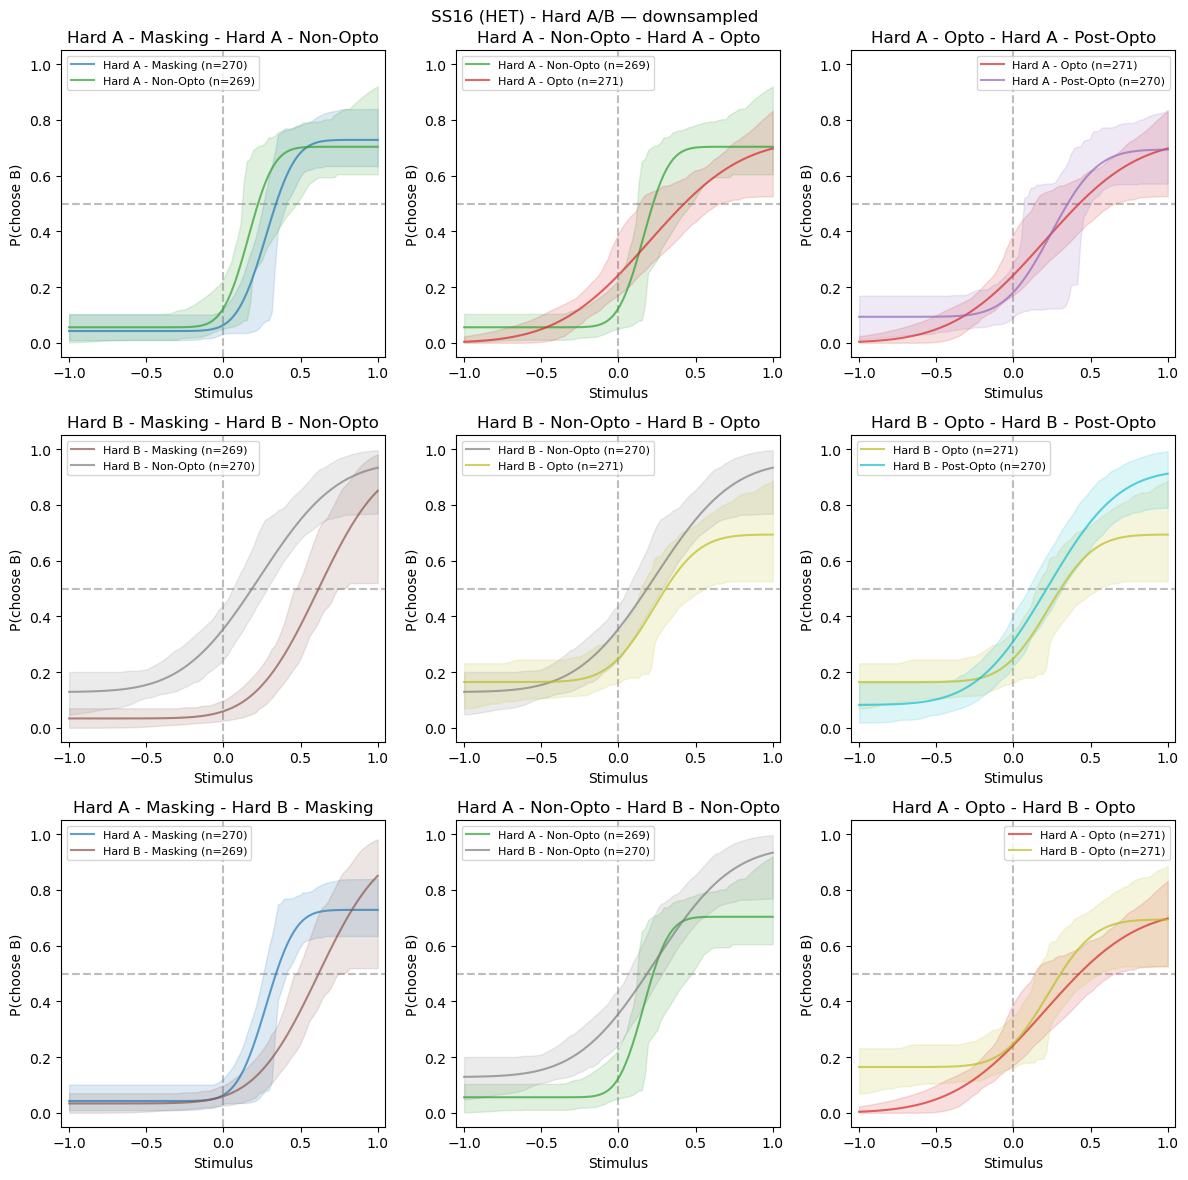

In [44]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for ax, pair in zip(axes, plotting_pairs):
    title = ''
    for idx in pair:
        p = phases_hard_ds[idx]
        if p.psyc_fit is None:
            continue
        plot_psychometric(p.psyc_fit, ax=ax, color=p.color, label=f'{p.label} (n={p.pooled["n_trials"]})')
        title += f'{p.label} - '
    ax.set_title(title.rstrip(' -'))
    ax.legend(fontsize=8)

fig.suptitle(f'{tag} - Hard A/B — downsampled')
fig.tight_layout()

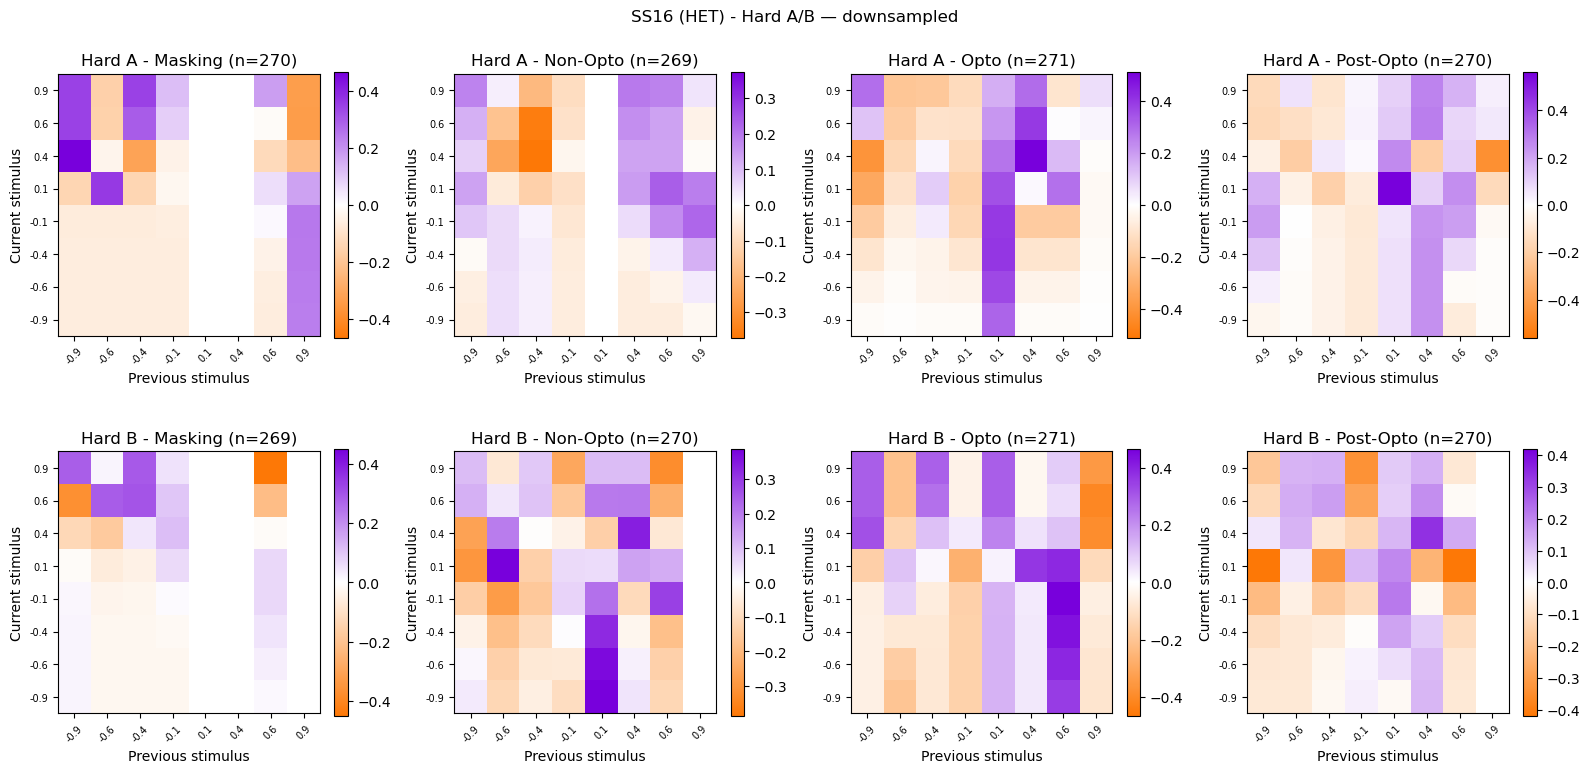

In [45]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, idx in zip(axes, [0, 2, 3, 4, 5, 7, 8, 9]):
    p = phases_hard_ds[idx]
    if p.um_fit is None:
        continue
    plot_um(p.um_fit[0], ax=ax)
    ax.set_title(f'{p.label} (n={p.pooled["n_trials"]})')

fig.suptitle(f'{tag} - Hard A/B — downsampled')
fig.tight_layout()

## Summary statistics by condition (downsampled hard)

In [61]:
DISTS = ('uniform', 'hard_a', 'hard_b')

rows = []
for p in phases_hard_ds:
    if not p.stats:                         # phase had no surviving sessions
        continue
    dist = next(d for d in DISTS if p.phase.startswith(d))
    session_type = p.phase[len(dist) + 1:]  # 'masking' / 'opto'
    cond = f'{session_type}-{p.trial_spec}'
    for metric, values in p.stats.items():
        for v in np.atleast_1d(values):
            rows.append({
                'phase': p.phase, 'dist': dist, 'session_type': session_type,
                'trial_spec': p.trial_spec, 'cond': cond, 'label': p.label,
                'metric': metric, 'value': v,
            })
df = pd.DataFrame(rows)
df.head()

,phase,dist,session_type,trial_spec,cond,label,metric,value
0,hard_a_masking,hard_a,masking,all,masking-all,Hard A - Masking,accuracy,0.730463
1,hard_a_masking,hard_a,masking,all,masking-all,Hard A - Masking,accuracy,0.644531
2,hard_a_masking,hard_a,masking,all,masking-all,Hard A - Masking,accuracy,0.680101
3,hard_a_masking,hard_a,masking,all,masking-all,Hard A - Masking,win_stay,-0.071977
4,hard_a_masking,hard_a,masking,all,masking-all,Hard A - Masking,win_stay,-0.106831


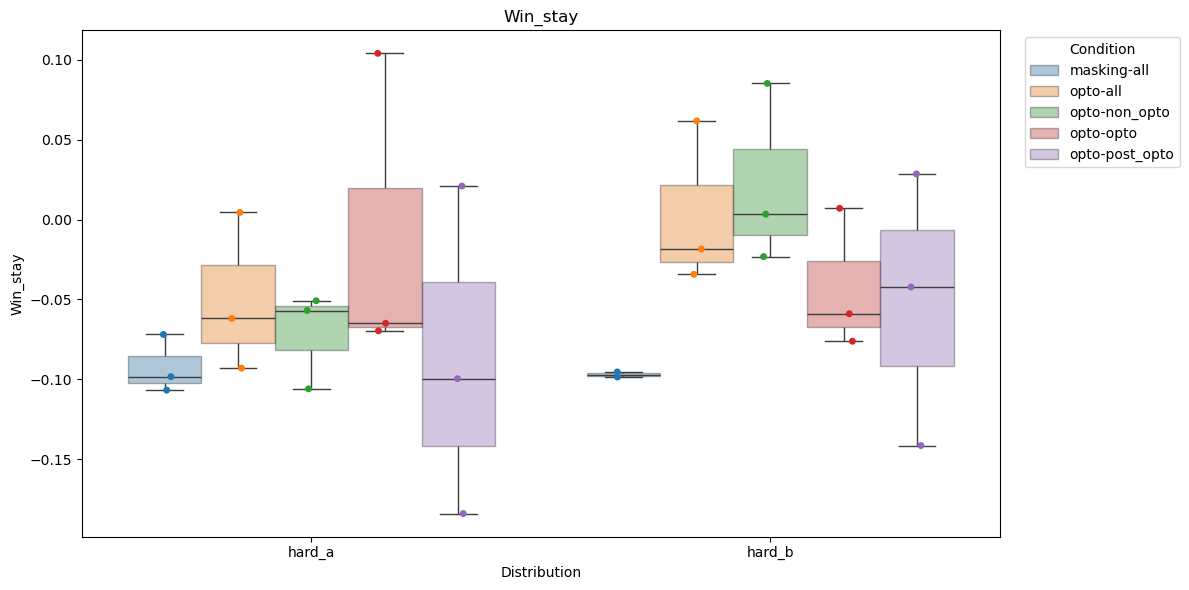

In [62]:
import seaborn as sns

metric_oi = 'win_stay'
sub = df[df['metric'] == metric_oi]

plt.figure(figsize=(12, 6))
sns.boxplot(data=sub, x='dist', y='value', hue='cond', boxprops={'alpha': 0.4})
sns.stripplot(data=sub, x='dist', y='value', hue='cond', dodge=True, legend=False)
plt.title(metric_oi.capitalize()); plt.xlabel('Distribution'); plt.ylabel(metric_oi.capitalize())
plt.legend(title='Condition', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

## Batch: all animals → PDF

_Not yet implemented — placeholder._

In [21]:
# from matplotlib.backends.backend_pdf import PdfPages
# OUTPUT_DIR = Path('outputs/animal_reports')
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# for aid, an in experiment.animals.items():
#     ... build the per-animal figures above, save into a PdfPages ...